## Gas Sales Product Type Prediction

Given *weekly reports of gas sales*, let's try to classify the **type** of a given product.

We will use a Tensorflow ANN to make our predictions.

Data source: https://www.kaggle.com/datasets/matheusfreitag/gas-prices-in-brazil

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/2004-2021.tsv', delimiter='\t')
data

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.090,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.050,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,2021-04-25,2021-05-01,NORTE,RORAIMA,OLEO DIESEL S10,12,R$/l,4.582,0.056,4.510,4.690,-99999.0,0.012,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120819,2021-04-25,2021-05-01,SUL,SANTA CATARINA,OLEO DIESEL S10,100,R$/l,4.141,0.187,3.838,4.739,-99999.0,0.045,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120820,2021-04-25,2021-05-01,SUDESTE,SAO PAULO,OLEO DIESEL S10,886,R$/l,4.246,0.216,3.769,5.199,-99999.0,0.051,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120821,2021-04-25,2021-05-01,NORDESTE,SERGIPE,OLEO DIESEL S10,33,R$/l,4.464,0.205,4.190,4.699,-99999.0,0.046,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120823 entries, 0 to 120822
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   DATA INICIAL                   120823 non-null  object 
 1   DATA FINAL                     120823 non-null  object 
 2   REGIÃO                         120823 non-null  object 
 3   ESTADO                         120823 non-null  object 
 4   PRODUTO                        120823 non-null  object 
 5   NÚMERO DE POSTOS PESQUISADOS   120823 non-null  int64  
 6   UNIDADE DE MEDIDA              120823 non-null  object 
 7   PREÇO MÉDIO REVENDA            120823 non-null  float64
 8   DESVIO PADRÃO REVENDA          120823 non-null  float64
 9   PREÇO MÍNIMO REVENDA           120823 non-null  float64
 10  PREÇO MÁXIMO REVENDA           120823 non-null  float64
 11  MARGEM MÉDIA REVENDA           120823 non-null  object 
 12  COEF DE VARIAÇÃO REVENDA      

### Preprocessing

In [4]:
data.isna().sum()

DATA INICIAL                     0
DATA FINAL                       0
REGIÃO                           0
ESTADO                           0
PRODUTO                          0
NÚMERO DE POSTOS PESQUISADOS     0
UNIDADE DE MEDIDA                0
PREÇO MÉDIO REVENDA              0
DESVIO PADRÃO REVENDA            0
PREÇO MÍNIMO REVENDA             0
PREÇO MÁXIMO REVENDA             0
MARGEM MÉDIA REVENDA             0
COEF DE VARIAÇÃO REVENDA         0
PREÇO MÉDIO DISTRIBUIÇÃO         0
DESVIO PADRÃO DISTRIBUIÇÃO       0
PREÇO MÍNIMO DISTRIBUIÇÃO        0
PREÇO MÁXIMO DISTRIBUIÇÃO        0
COEF DE VARIAÇÃO DISTRIBUIÇÃO    0
dtype: int64

#### Class Visualization

In [5]:
data['PRODUTO'].value_counts()

PRODUTO
GASOLINA COMUM        23570
GLP                   23561
ETANOL HIDRATADO      23440
ÓLEO DIESEL           21194
GNV                   14469
ÓLEO DIESEL S10        9113
OLEO DIESEL S10        2376
OLEO DIESEL            2351
GASOLINA ADITIVADA      749
Name: count, dtype: int64

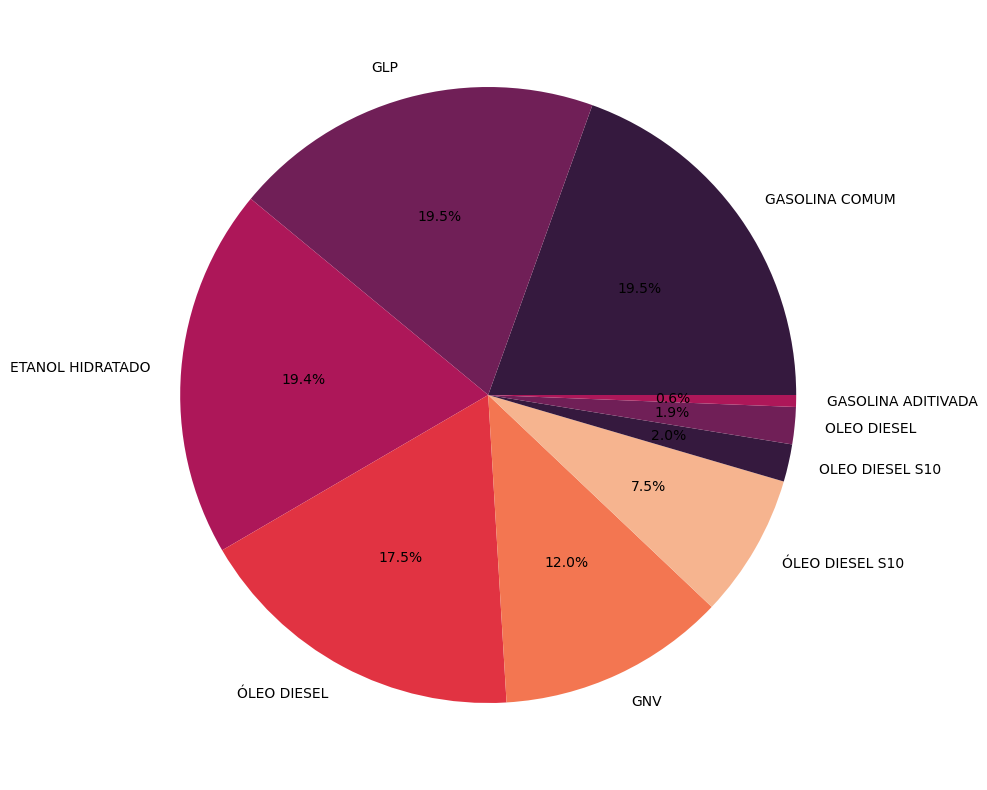

In [6]:
plt.figure(figsize=(10,10))
plt.pie(
    x = data['PRODUTO'].value_counts(),
    labels = data['PRODUTO'].value_counts().index,
    autopct = '%.1f%%',
    colors = sns.color_palette('rocket')
)
plt.show()

In [7]:
data

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.090,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.050,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,2021-04-25,2021-05-01,NORTE,RORAIMA,OLEO DIESEL S10,12,R$/l,4.582,0.056,4.510,4.690,-99999.0,0.012,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120819,2021-04-25,2021-05-01,SUL,SANTA CATARINA,OLEO DIESEL S10,100,R$/l,4.141,0.187,3.838,4.739,-99999.0,0.045,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120820,2021-04-25,2021-05-01,SUDESTE,SAO PAULO,OLEO DIESEL S10,886,R$/l,4.246,0.216,3.769,5.199,-99999.0,0.051,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
120821,2021-04-25,2021-05-01,NORDESTE,SERGIPE,OLEO DIESEL S10,33,R$/l,4.464,0.205,4.190,4.699,-99999.0,0.046,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0


In [8]:
data['DATA INICIAL'] = pd.to_datetime(data['DATA INICIAL'])
data['YEAR'] = data['DATA INICIAL'].apply(lambda x: x.year)
data['MONTH'] = data['DATA INICIAL'].apply(lambda x: x.month)
data = data.drop(['DATA INICIAL', 'DATA FINAL'], axis=1)

In [9]:
data

,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO,YEAR,MONTH
0,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133,2004,5
1,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115,2004,5
2,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098,2004,5
3,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.090,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143,2004,5
4,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.050,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082,2004,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,NORTE,RORAIMA,OLEO DIESEL S10,12,R$/l,4.582,0.056,4.510,4.690,-99999.0,0.012,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120819,SUL,SANTA CATARINA,OLEO DIESEL S10,100,R$/l,4.141,0.187,3.838,4.739,-99999.0,0.045,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120820,SUDESTE,SAO PAULO,OLEO DIESEL S10,886,R$/l,4.246,0.216,3.769,5.199,-99999.0,0.051,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120821,NORDESTE,SERGIPE,OLEO DIESEL S10,33,R$/l,4.464,0.205,4.190,4.699,-99999.0,0.046,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4


In [10]:
data['PRODUTO'] = data['PRODUTO'].replace('OLEO DIESEL S10', 'ÓLEO DIESEL S10')
data['PRODUTO'] = data['PRODUTO'].replace('OLEO DIESEL', 'ÓLEO DIESEL')

In [11]:
data['PRODUTO'].value_counts()

PRODUTO
GASOLINA COMUM        23570
GLP                   23561
ÓLEO DIESEL           23545
ETANOL HIDRATADO      23440
GNV                   14469
ÓLEO DIESEL S10       11489
GASOLINA ADITIVADA      749
Name: count, dtype: int64

#### Encoding

In [12]:
label_encoder = LabelEncoder()

data['PRODUTO'] = label_encoder.fit_transform(data['PRODUTO'])

In [13]:
dict(enumerate(label_encoder.classes_))

{0: 'ETANOL HIDRATADO',
 1: 'GASOLINA ADITIVADA',
 2: 'GASOLINA COMUM',
 3: 'GLP',
 4: 'GNV',
 5: 'ÓLEO DIESEL',
 6: 'ÓLEO DIESEL S10'}

In [14]:
data

,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO,YEAR,MONTH
0,CENTRO OESTE,DISTRITO FEDERAL,0,127,R$/l,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133,2004,5
1,CENTRO OESTE,GOIAS,0,387,R$/l,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115,2004,5
2,CENTRO OESTE,MATO GROSSO,0,192,R$/l,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098,2004,5
3,CENTRO OESTE,MATO GROSSO DO SUL,0,162,R$/l,1.262,0.070,1.090,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143,2004,5
4,NORDESTE,ALAGOAS,0,103,R$/l,1.181,0.078,1.050,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082,2004,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,NORTE,RORAIMA,6,12,R$/l,4.582,0.056,4.510,4.690,-99999.0,0.012,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120819,SUL,SANTA CATARINA,6,100,R$/l,4.141,0.187,3.838,4.739,-99999.0,0.045,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120820,SUDESTE,SAO PAULO,6,886,R$/l,4.246,0.216,3.769,5.199,-99999.0,0.051,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4
120821,NORDESTE,SERGIPE,6,33,R$/l,4.464,0.205,4.190,4.699,-99999.0,0.046,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,2021,4


In [15]:
{column: len(data[column].unique()) for column in data.columns if data.dtypes[column]=='object'}

{'REGIÃO': 5,
 'ESTADO': 27,
 'UNIDADE DE MEDIDA': 3,
 'MARGEM MÉDIA REVENDA': 12885,
 'PREÇO MÉDIO DISTRIBUIÇÃO': 17170,
 'DESVIO PADRÃO DISTRIBUIÇÃO': 6144,
 'PREÇO MÍNIMO DISTRIBUIÇÃO': 23163,
 'PREÇO MÁXIMO DISTRIBUIÇÃO': 24267,
 'COEF DE VARIAÇÃO DISTRIBUIÇÃO': 400}

In [16]:
def onehot_encode(df, columns, prefixes):
    df = df.copy()
    for column, prefix in zip(columns, prefixes):
        dummies = pd.get_dummies(df[column], prefix=prefix, dtype=int)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

In [17]:
nominal_columns = ['REGIÃO', 'ESTADO', 'UNIDADE DE MEDIDA']
nominal_column_prefixes = ['R', 'E', 'UM']

data = onehot_encode(data, nominal_columns, nominal_column_prefixes)

In [18]:
data

,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,...,E_RIO GRANDE DO SUL,E_RONDONIA,E_RORAIMA,E_SANTA CATARINA,E_SAO PAULO,E_SERGIPE,E_TOCANTINS,UM_R$/13Kg,UM_R$/l,UM_R$/m3
0,0,127,1.288,0.016,1.190,1.350,0.463,0.012,0.825,0.11,...,0,0,0,0,0,0,0,0,1,0
1,0,387,1.162,0.114,0.890,1.449,0.399,0.098,0.763,0.088,...,0,0,0,0,0,0,0,0,1,0
2,0,192,1.389,0.097,1.180,1.760,0.419,0.070,0.97,0.095,...,0,0,0,0,0,0,0,0,1,0
3,0,162,1.262,0.070,1.090,1.509,0.432,0.055,0.83,0.119,...,0,0,0,0,0,0,0,0,1,0
4,0,103,1.181,0.078,1.050,1.400,0.24,0.066,0.941,0.077,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,6,12,4.582,0.056,4.510,4.690,-99999.0,0.012,-99999.0,-99999.0,...,0,0,1,0,0,0,0,0,1,0
120819,6,100,4.141,0.187,3.838,4.739,-99999.0,0.045,-99999.0,-99999.0,...,0,0,0,1,0,0,0,0,1,0
120820,6,886,4.246,0.216,3.769,5.199,-99999.0,0.051,-99999.0,-99999.0,...,0,0,0,0,1,0,0,0,1,0
120821,6,33,4.464,0.205,4.190,4.699,-99999.0,0.046,-99999.0,-99999.0,...,0,0,0,0,0,1,0,0,1,0


#### Missing values

In [19]:
data.isin(['-']).sum()

PRODUTO                             0
NÚMERO DE POSTOS PESQUISADOS        0
PREÇO MÉDIO REVENDA                 0
DESVIO PADRÃO REVENDA               0
PREÇO MÍNIMO REVENDA                0
PREÇO MÁXIMO REVENDA                0
MARGEM MÉDIA REVENDA             3431
COEF DE VARIAÇÃO REVENDA            0
PREÇO MÉDIO DISTRIBUIÇÃO         3400
DESVIO PADRÃO DISTRIBUIÇÃO       3400
PREÇO MÍNIMO DISTRIBUIÇÃO        3400
PREÇO MÁXIMO DISTRIBUIÇÃO        3400
COEF DE VARIAÇÃO DISTRIBUIÇÃO    3400
YEAR                                0
MONTH                               0
R_CENTRO OESTE                      0
R_NORDESTE                          0
R_NORTE                             0
R_SUDESTE                           0
R_SUL                               0
E_ACRE                              0
E_ALAGOAS                           0
E_AMAPA                             0
E_AMAZONAS                          0
E_BAHIA                             0
E_CEARA                             0
E_DISTRITO F

In [20]:
data = data.replace('-', np.nan)

In [21]:
data = data.astype(float)

In [22]:
for column in data.columns:
    data[column] = data[column].fillna(data[column].mean())

In [23]:
data.isna().sum().sum()

np.int64(0)

#### Splitting and Scaling

In [24]:
y = data['PRODUTO']
X = data.drop('PRODUTO', axis=1)

In [25]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [26]:
X

array([[-0.24247768, -0.53155079, -0.47611107, ..., -0.49218147,
         0.67774505, -0.36884368],
       [ 0.42773141, -0.5381264 , -0.40627624, ..., -0.49218147,
         0.67774505, -0.36884368],
       [-0.07492541, -0.52627988, -0.41839044, ..., -0.49218147,
         0.67774505, -0.36884368],
       ...,
       [ 1.71401733, -0.37718071, -0.333591  , ..., -0.49218147,
         0.67774505, -0.36884368],
       [-0.48478405, -0.36580388, -0.3414296 , ..., -0.49218147,
         0.67774505, -0.36884368],
       [-0.52344996, -0.37164886, -0.37634702, ..., -0.49218147,
         0.67774505, -0.36884368]], shape=(120823, 49))

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=34)

### Training

In [28]:
class_weights = dict(enumerate(class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = y_train.unique(),
    y = y_train
)))

class_weights

{0: np.float64(0.7371742351608124),
 1: np.float64(0.7329704995320138),
 2: np.float64(0.7328371270871422),
 3: np.float64(0.733370908302623),
 4: np.float64(1.1897868748681157),
 5: np.float64(1.498299319727891),
 6: np.float64(23.190567589799837)}

In [29]:
X.shape

(120823, 49)

In [30]:
num_classes = len(y.unique())
num_classes

7

In [32]:
inputs = tf.keras.Input(shape=(X.shape[1],))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

batch_size = 32
epochs = 100

history = model.fit(
    X_train, 
    y_train,
    validation_split=0.2,
    class_weight=class_weights,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5539 - loss: 1.5144 - val_accuracy: 0.6146 - val_loss: 1.0492
Epoch 2/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6309 - loss: 1.2149 - val_accuracy: 0.6447 - val_loss: 0.9679
Epoch 3/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6781 - loss: 1.0674 - val_accuracy: 0.6959 - val_loss: 0.8027
Epoch 4/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7229 - loss: 0.9536 - val_accuracy: 0.7247 - val_loss: 0.7906
Epoch 5/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7523 - loss: 0.8746 - val_accuracy: 0.7512 - val_loss: 0.7338
Epoch 6/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7730 - loss: 0.8130 - val_accuracy: 0.7835 - val_loss: 0.6230
Epoch 7/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7873 - loss: 0.7671 - val_accuracy: 0.7862 - val_loss: 0.6370
Epoch 8/100
2115/2115 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7976 - loss: 0

### Results

In [33]:
model.evaluate(X_test, y_test)

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8423 - loss: 0.4320


[0.4320453405380249, 0.8423041701316833]